In [1]:

import numpy as np
import pandas as pd
import os
import warnings
import gc  # Garbage collector for manual memory cleanup
warnings.filterwarnings('ignore')

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

# Class Balancing
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

from collections import Counter
import time

# Random Seeds
np.random.seed(42)
tf.random.set_seed(42)

# GPU Configuration
print("=" * 60)
print("GPU-ACCELERATED INTRUSION DETECTION SYSTEM")
print("=" * 60)
print(f"\nTensorFlow Version: {tf.__version__}")

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU Available: {len(gpus)} GPU(s) detected")
    for i, gpu in enumerate(gpus):
        print(f"  GPU {i}: {gpu}")

    # Configure GPU memory growth to avoid OOM errors
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU memory growth enabled")
    except RuntimeError as e:
        print(f"Warning: {e}")
else:
    print("⚠ No GPU detected - will use CPU (slower)")

print("=" * 60)


GPU-ACCELERATED INTRUSION DETECTION SYSTEM

TensorFlow Version: 2.19.0
✓ GPU Available: 1 GPU(s) detected
  GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✓ GPU memory growth enabled


# SECTION 1: DATA LOADING (Memory-Efficient)


In [2]:
base_path = '/content/Datasets'

# Find all CSV files
try:
    csv_files = [f for f in os.listdir(base_path) if f.endswith('csv')]
    print(f"\nFound {len(csv_files)} CSV files:")
    for i, file in enumerate(csv_files, 1):
        print(f"  {i}. {file}")
except:
    print("The base path for the dataset is not correct.")
    csv_files = []

# Load and combine CSV files with memory optimization
if csv_files:
    print("\nLoading CSV files with memory optimization...")

    # Load first file to get structure
    df = pd.read_csv(os.path.join(base_path, csv_files[0]), encoding='utf-8')
    print(f"Loaded {csv_files[0]}: {df.shape}")

    # Load remaining files one by one and append
    for file in csv_files[1:]:
        try:
            df_temp = pd.read_csv(os.path.join(base_path, file), encoding='utf-8')
            print(f"Loaded {file}: {df_temp.shape}")
            df = pd.concat([df, df_temp], ignore_index=True)

            # MEMORY CLEANUP: Delete temporary dataframe
            del df_temp
            gc.collect()

        except Exception as e:
            print(f"Error loading {file}: {e}")

    print(f"\n✓ Total Dataset: {df.shape}")
    print(f"  Total Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
else:
    print("No CSV files found. Creating empty DataFrame.")
    df = pd.DataFrame()

# Display first few rows
if not df.empty:
    print("\nFirst 5 rows:")
    print(df.head())



Found 8 CSV files:
  1. Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  2. Wednesday-workingHours.pcap_ISCX.csv
  3. Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  4. Monday-WorkingHours.pcap_ISCX.csv
  5. Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  6. Tuesday-WorkingHours.pcap_ISCX.csv
  7. Friday-WorkingHours-Morning.pcap_ISCX.csv
  8. Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

Loading CSV files with memory optimization...
Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (288602, 79)
Loaded Wednesday-workingHours.pcap_ISCX.csv: (692703, 79)
Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (286467, 79)
Loaded Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)
Loaded Tuesday-WorkingHours.pcap_ISCX.csv: (445909, 79)
Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: (191033, 79)
Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (170366,

# SECTION 2: DATASET EXPLORATION

In [3]:
print("\n" + "=" * 60)
print("DATASET EXPLORATION")
print("=" * 60)

print(f"\nDataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

# Column names and datatypes
print(f"\nColumn Data Types:")
print(df.dtypes.value_counts())

# Find Label Column
label_col = 'Label' if 'Label' in df.columns else ' Label' if ' Label' in df.columns else None

if label_col:
    print(f"\nTarget Variable: '{label_col}'")
    print(f"\nAttack Type Distribution:")
    attack_counts = df[label_col].value_counts()
    print(attack_counts)

    print(f"\nPercentage Distribution:")
    print((df[label_col].value_counts(normalize=True) * 100).round(2))
else:
    print("WARNING: Label Column not Found!")

# Missing values
print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values(by='Missing_Count', ascending=False).head(10)
print(missing_df[missing_df['Missing_Count'] > 0])

# Statistical Summary
print(f"\nStatistical Summary (first 5 numeric columns):")
print(df.describe().iloc[:, :5].T)


DATASET EXPLORATION

Dataset Dimensions: 2,830,743 rows x 79 columns
Memory Usage: 1833.87 MB

Column Data Types:
int64      54
float64    24
object      1
Name: count, dtype: int64

Target Variable: ' Label'

Attack Type Distribution:
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Percentage Distribution:
 Label
BENIGN                        80.30
DoS Hulk                       8.16
PortScan                       5.61
DDoS               

# SECTION 3: EDA - ATTACK DISTRIBUTION


EDA - ATTACK DISTRIBUTION


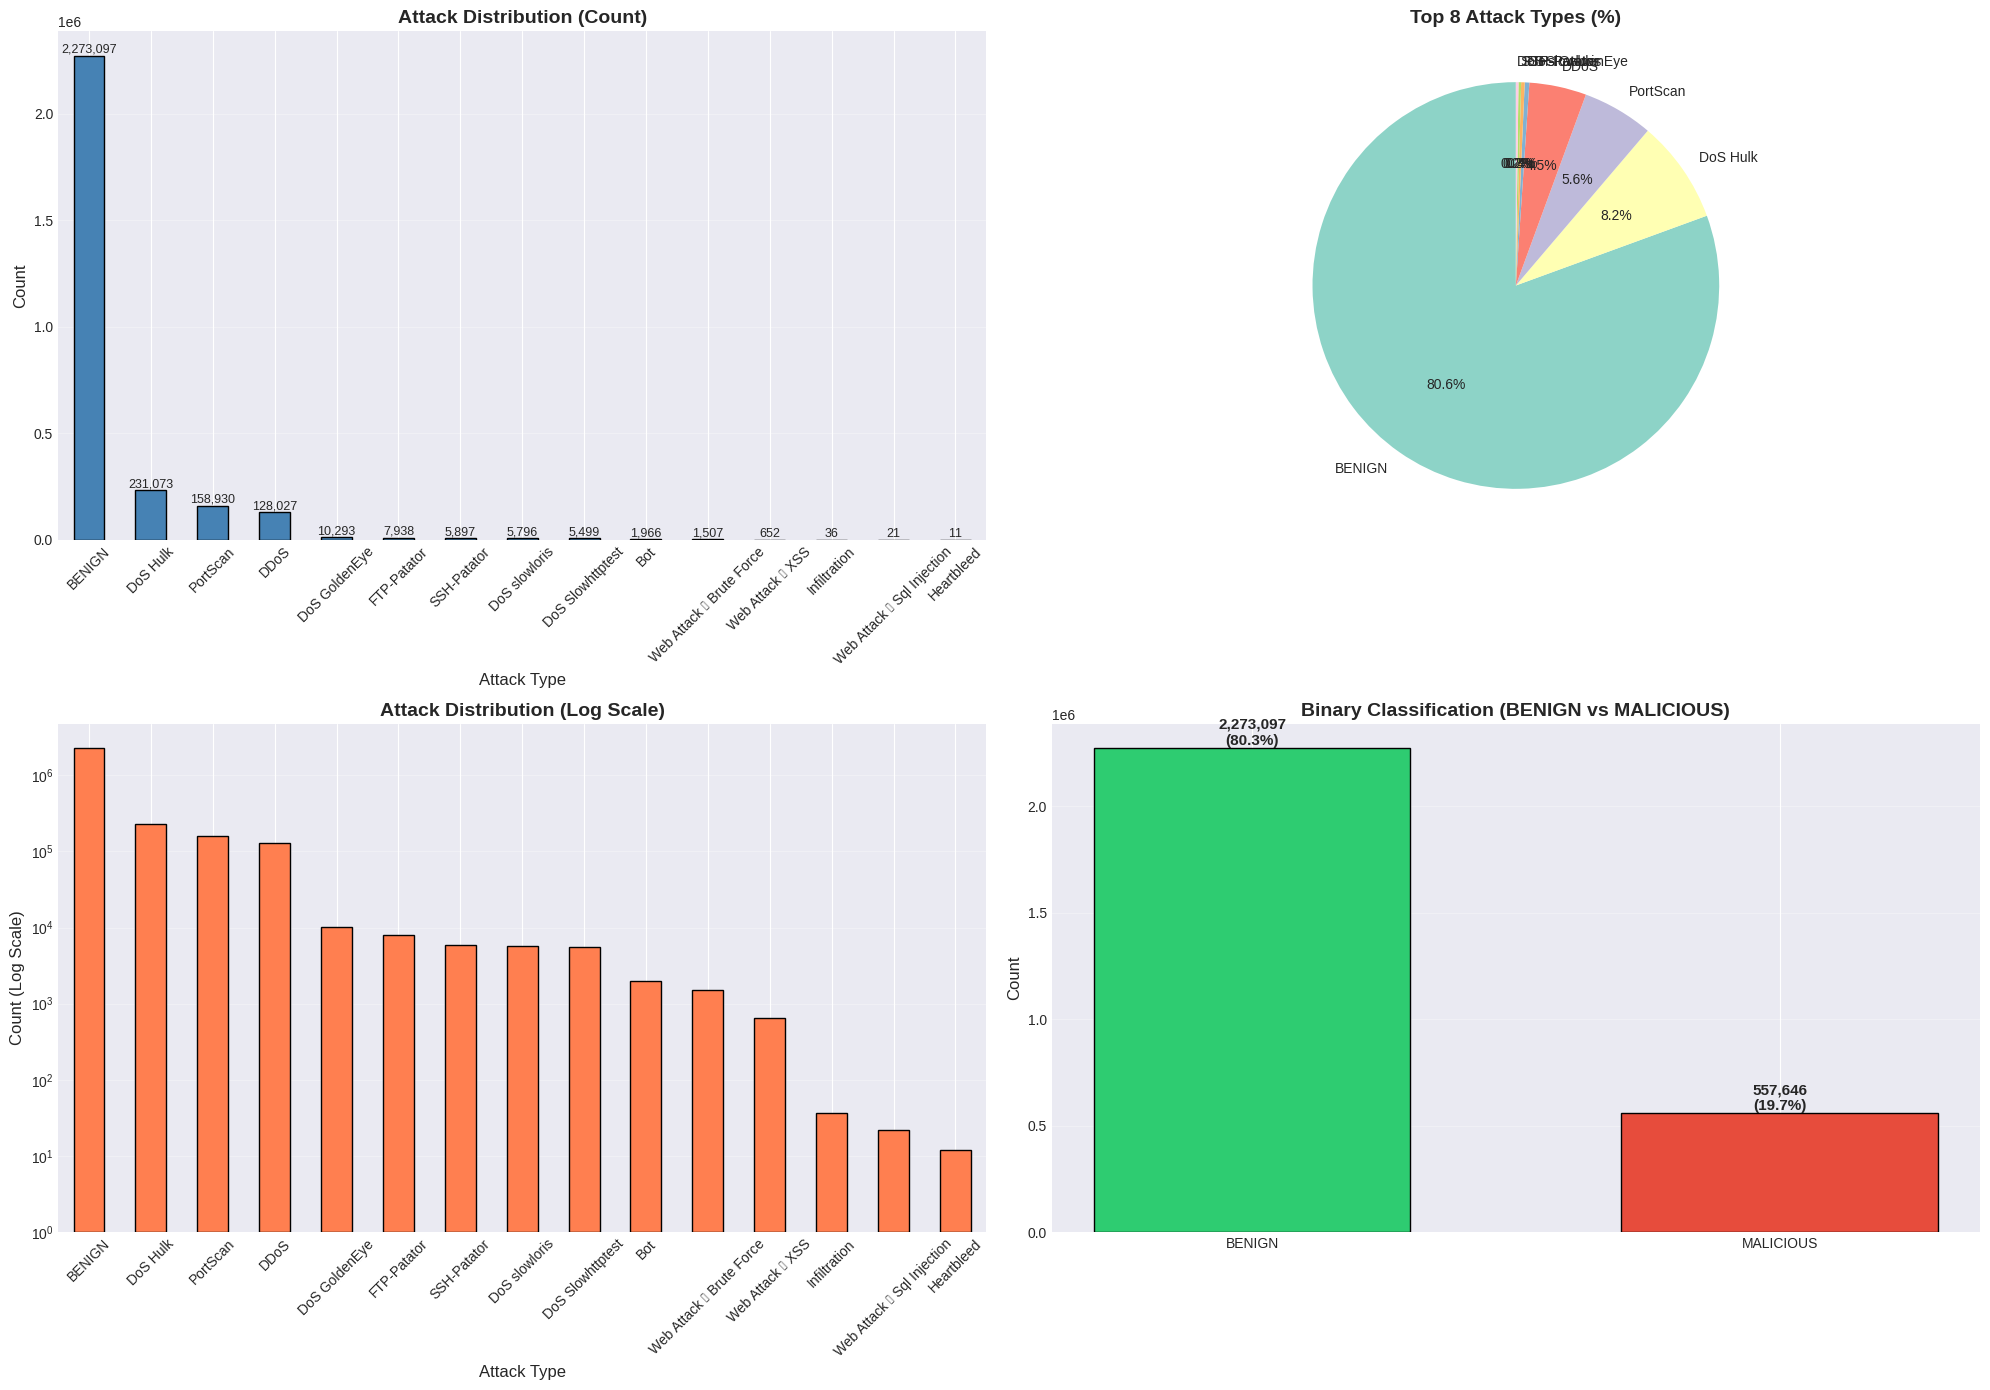


Key Statistics:
  Total Samples: 2,830,743
  Benign Traffic: 2,273,097 (80.30%)
  Malicious Traffic: 557,646 (19.70%)
  Number of Attack Types: 15
  Imbalance Ratio: 1:257340


In [4]:
print("\n" + "=" * 60)
print("EDA - ATTACK DISTRIBUTION")
print("=" * 60)

if label_col and not df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))

    # 1. Attack Type Count Bar Plot
    attack_counts = df[label_col].value_counts()
    ax1 = axes[0, 0]
    attack_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_title('Attack Distribution (Count)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Attack Type', fontsize=12)
    ax1.set_ylabel('Count', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)

    # Add count labels
    for i, v in enumerate(attack_counts.values):
        ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

    # 2. Pie Chart - Top 8 Attacks
    ax2 = axes[0, 1]
    top_attacks = attack_counts.head(8)
    colors = plt.cm.Set3(range(len(top_attacks)))
    ax2.pie(top_attacks.values, labels=top_attacks.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
    ax2.set_title('Top 8 Attack Types (%)', fontsize=14, fontweight='bold')

    # 3. Log Scale Distribution
    ax3 = axes[1, 0]
    attack_counts.plot(kind='bar', ax=ax3, color='coral', edgecolor='black', log=True)
    ax3.set_title('Attack Distribution (Log Scale)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Attack Type', fontsize=12)
    ax3.set_ylabel('Count (Log Scale)', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(axis='y', alpha=0.3)

    # 4. Binary Classification
    ax4 = axes[1, 1]
    binary_dist = df[label_col].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'MALICIOUS').value_counts()
    colors_binary = ['#2ecc71', '#e74c3c']
    ax4.bar(binary_dist.index, binary_dist.values, color=colors_binary, edgecolor='black', width=0.6)
    ax4.set_title('Binary Classification (BENIGN vs MALICIOUS)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Count', fontsize=12)
    ax4.grid(axis='y', alpha=0.3)

    # Add count labels
    for i, v in enumerate(binary_dist.values):
        ax4.text(i, v, f"{v:,}\n({v/len(df)*100:.1f}%)", ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig('attack_distribution_gpu.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Key Statistics
    print('\nKey Statistics:')
    print(f"  Total Samples: {len(df):,}")
    print(f"  Benign Traffic: {(df[label_col]=='BENIGN').sum():,} ({(df[label_col]=='BENIGN').sum()/len(df)*100:.2f}%)")
    print(f"  Malicious Traffic: {(df[label_col] != 'BENIGN').sum():,} ({(df[label_col] != 'BENIGN').sum()/len(df)*100:.2f}%)")
    print(f"  Number of Attack Types: {df[label_col].nunique()}")
    print(f"  Imbalance Ratio: 1:{len(df)//attack_counts.min()}")

# SECTION 4: FEATURE ANALYSIS


FEATURE ANALYSIS

Total Numeric Features: 78

Checking for zero-variance features...
Found 8 zero-variance features
Examples: [' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Creating binary target for correlation analysis...
Calculating feature correlations with target...


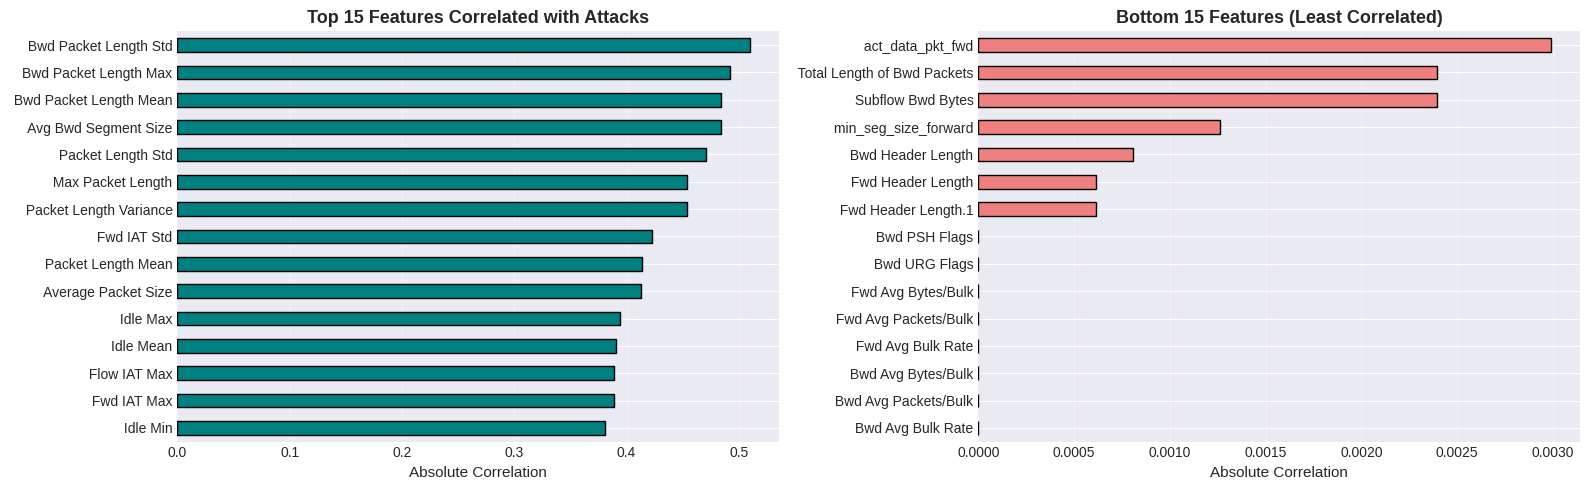


Top 10 Most Important Features (by correlation):
   1.  Bwd Packet Length Std                  : 0.5102
   2. Bwd Packet Length Max                   : 0.4920
   3.  Bwd Packet Length Mean                 : 0.4842
   4.  Avg Bwd Segment Size                   : 0.4842
   5.  Packet Length Std                      : 0.4703
   6.  Max Packet Length                      : 0.4541
   7.  Packet Length Variance                 : 0.4538
   8.  Fwd IAT Std                            : 0.4228
   9.  Packet Length Mean                     : 0.4141
  10.  Average Packet Size                    : 0.4130


In [5]:
print("\n" + "=" * 60)
print("FEATURE ANALYSIS")
print("=" * 60)

if not df.empty:
    # Select only numeric features
    numeric_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c != 'is_attack'
    ]

    # Remove infinite values (in-place to save memory)
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

    print(f"\nTotal Numeric Features: {len(numeric_cols)}")

    # Zero variance features
    print("\nChecking for zero-variance features...")
    zero_var_features = df[numeric_cols].std()[df[numeric_cols].std() == 0].index.tolist()
    print(f"Found {len(zero_var_features)} zero-variance features")
    if zero_var_features:
        print(f"Examples: {zero_var_features[:10]}")

    # Create binary target
    if label_col:
        print(f"\nCreating binary target for correlation analysis...")
        df['is_attack'] = (df[label_col] != 'BENIGN').astype(int)

        # Calculate correlations
        print("Calculating feature correlations with target...")
        correlations = df[numeric_cols + ['is_attack']].corr().loc[numeric_cols, 'is_attack'].abs().sort_values(ascending=False)

        # Plot top correlated features
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # Top 15 correlated features
        ax1 = axes[0]
        top_corr = correlations.head(15)
        top_corr.plot(kind='barh', ax=ax1, color='teal', edgecolor='black')
        ax1.set_title('Top 15 Features Correlated with Attacks', fontsize=13, fontweight='bold')
        ax1.set_xlabel('Absolute Correlation', fontsize=11)
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)

        # Bottom 15 (least correlated)
        ax2 = axes[1]
        bottom_corr = correlations.tail(15)
        bottom_corr.plot(kind='barh', ax=ax2, color='lightcoral', edgecolor='black')
        ax2.set_title('Bottom 15 Features (Least Correlated)', fontsize=13, fontweight='bold')
        ax2.set_xlabel('Absolute Correlation', fontsize=11)
        ax2.invert_yaxis()
        ax2.grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig('feature_correlations_gpu.png', dpi=100, bbox_inches='tight')
        plt.show()

        print("\nTop 10 Most Important Features (by correlation):")
        for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
            print(f"  {i:2d}. {feat:40s}: {corr:.4f}")

# SECTION 5: DATA PREPROCESSING (Memory-Efficient)

In [6]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import gc

print("\n" + "=" * 60)
print("DATA PREPROCESSING WITH PROGRESSIVE BALANCING")
print("=" * 60)

if not df.empty and label_col:
    print("\nStep 1: Preparing features and labels...")

    # Separate features and target
    X = df.drop(columns=[label_col, 'is_attack'])
    y = df[label_col].copy()

    # MEMORY CLEANUP: Remove original dataframe
    del df
    gc.collect()
    print(f"  ✓ Original dataframe cleared from memory")

    # Handle infinite values and missing values TOGETHER
    print("\nStep 2: Handling infinite and missing values...")

    # Replace infinite values with NaN
    X = X.replace([np.inf, -np.inf], pd.NA)

    # Find rows with any NaN values (after infinite replacement)
    na_mask = X.isna().any(axis=1)

    # Remove corresponding rows from both X and y
    if na_mask.any():
        print(f"  Found {na_mask.sum():,} rows with infinite/missing values")
        X = X[~na_mask].copy()
        y = y[~na_mask].copy()
        print(f"  Removed {na_mask.sum():,} rows")

    # Fill any remaining missing values with 0
    X = X.fillna(0)

    print(f"  ✓ Cleaned dataset: {X.shape[0]:,} samples, {X.shape[1]:,} features")

    # Encode labels
    print("\nStep 3: Encoding labels...")
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    n_classes = len(le.classes_)
    print(f"  ✓ Encoded {n_classes} unique attack types")
    print(f"  Classes: {list(le.classes_)[:5]}..." if n_classes > 5 else f"  Classes: {list(le.classes_)}")

    # Verify shape consistency
    assert X.shape[0] == len(y_encoded), f"Mismatch: X has {X.shape[0]} rows, y has {len(y_encoded)}"

    # MEMORY CLEANUP: Remove original labels
    del y
    gc.collect()

    # Train-test split
    print("\nStep 4: Splitting data (80% train, 20% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    print(f"  ✓ Training set: {X_train.shape[0]:,} samples")
    print(f"  ✓ Test set: {X_test.shape[0]:,} samples")

    # MEMORY CLEANUP: Remove full X and y_encoded
    del X, y_encoded
    gc.collect()
    print(f"  ✓ Full dataset cleared from memory")

    # Feature scaling
    print("\nStep 5: Scaling features...")
    scaler = StandardScaler()

    # Scale training data
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

    # MEMORY CLEANUP: Remove unscaled training data
    del X_train
    gc.collect()

    # Scale test data
    X_test_scaled = scaler.transform(X_test)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    # MEMORY CLEANUP: Remove unscaled test data
    del X_test
    gc.collect()

    print(f"  ✓ Features scaled using StandardScaler")
    print(f"  ✓ Unscaled data cleared from memory")

    # Store feature names
    feature_names = list(X_train_scaled.columns)

    # Class distribution before balancing
    print("\nStep 6: Progressive balancing with undersampling...")
    print("\n  Class distribution BEFORE balancing:")
    class_counts_before = Counter(y_train)
    for class_label, count in sorted(class_counts_before.items()):
        class_name = le.inverse_transform([class_label])[0]
        print(f"    {class_name:30s}: {count:,} samples")

    # ========================================================
    # NEW: PROGRESSIVE BALANCING WITH UNDERSAMPLING
    # ========================================================
    print("\n" + "-" * 60)
    print("PROGRESSIVE BALANCING PROCESS")
    print("-" * 60)

    # 1. First undersample BENIGN class (assumed to be class 0)
    print("\n  Phase 1: Undersampling BENIGN class...")
    benign_class = 0
    benign_mask = (y_train == benign_class)
    X_benign = X_train_scaled[benign_mask]
    y_benign = y_train[benign_mask]

    print(f"    Original BENIGN samples: {len(X_benign):,}")

    # Undersample to 15%
    from sklearn.utils import resample
    undersample_ratio = 0.15
    n_benign_target = int(len(X_benign) * undersample_ratio)

    X_benign_down, y_benign_down = resample(
        X_benign, y_benign,
        n_samples=n_benign_target,
        random_state=42,
        replace=False
    )

    print(f"    After 25% undersampling: {len(X_benign_down):,} samples")

    # Clean up memory
    del X_benign, y_benign
    gc.collect()

    # 2. Set target size for minority classes (e.g., 50% of undersampled BENIGN)
    target_multiplier = 0.5  # Adjust this (0.3 to 2.0 based on your needs)
    target_size = int(len(X_benign_down) * target_multiplier)
    print(f"\n  Target size for minority classes: {target_size:,} samples")

    # 3. Process each minority class progressively
    print("\n  Phase 2: Processing minority classes...")
    minority_classes = [c for c in np.unique(y_train) if c != benign_class]

    # Start with undersampled BENIGN
    balanced_parts_X = [X_benign_down]
    balanced_parts_y = [y_benign_down]

    # Clean up
    del X_benign_down, y_benign_down
    gc.collect()

    # Process each minority class
    for i, class_label in enumerate(minority_classes, 1):
        class_name = le.inverse_transform([class_label])[0]
        print(f"\n    Processing {class_name}... ({i}/{len(minority_classes)})")

        # Get original samples for this class
        class_mask = (y_train == class_label)
        X_class_original = X_train_scaled[class_mask]
        y_class_original = y_train[class_mask]

        original_count = len(X_class_original)
        print(f"      Original samples: {original_count:,}")

        # If already at or above target size, keep as is
        if original_count >= target_size:
            print(f"      Already at target, keeping original samples")
            balanced_parts_X.append(X_class_original)
            balanced_parts_y.append(y_class_original)
            continue

        # Calculate how many synthetic samples to generate
        samples_needed = target_size - original_count
        print(f"      Need {samples_needed:,} synthetic samples")

        # For classes with very few samples, use smaller k_neighbors
        k_neighbors = min(5, original_count - 1) if original_count > 1 else 1

        # Apply SMOTE to generate synthetic samples
        if original_count > 0 and samples_needed > 0:
            # SMOTE needs at least 2 classes, so combine with a few BENIGN samples
            # Take a small subset of already processed BENIGN samples
            n_benign_for_smote = min(100, len(balanced_parts_X[0]))
            X_temp_benign = balanced_parts_X[0].iloc[:n_benign_for_smote]
            y_temp_benign = balanced_parts_y[0][:n_benign_for_smote]

            # Combine for SMOTE
            X_for_smote = pd.concat([X_temp_benign, X_class_original], axis=0)
            y_for_smote = np.concatenate([y_temp_benign, y_class_original])

            # Create custom sampling strategy
            sampling_dict = {
                benign_class: n_benign_for_smote,  # Keep BENIGN as is
                class_label: target_size  # Target for this minority class
            }

            # Apply SMOTE
            smote = SMOTE(
                sampling_strategy=sampling_dict,
                k_neighbors=k_neighbors,
                random_state=42
            )

            X_resampled, y_resampled = smote.fit_resample(X_for_smote, y_for_smote)

            # Extract only the oversampled minority class (not BENIGN)
            minority_indices = (y_resampled == class_label)
            X_class_balanced = X_resampled[minority_indices]
            y_class_balanced = y_resampled[minority_indices]

            print(f"      Generated {len(X_class_balanced) - original_count:,} synthetic samples")

            balanced_parts_X.append(X_class_balanced)
            balanced_parts_y.append(y_class_balanced)

            # Clean up
            del X_resampled, y_resampled, X_for_smote, y_for_smote
            gc.collect()

        # Clean up original class data
        del X_class_original, y_class_original
        gc.collect()

    # 4. Combine all balanced parts
    print("\n  Phase 3: Combining all balanced data...")

    # Convert to DataFrames/arrays for concatenation
    X_balanced_parts_dfs = []
    for X_part in balanced_parts_X:
        if isinstance(X_part, pd.DataFrame):
            X_balanced_parts_dfs.append(X_part)
        else:
            X_balanced_parts_dfs.append(pd.DataFrame(X_part, columns=feature_names))

    X_train_balanced = pd.concat(X_balanced_parts_dfs, axis=0, ignore_index=True)
    y_train_balanced = np.concatenate(balanced_parts_y)

    # Clean up
    del balanced_parts_X, balanced_parts_y, X_balanced_parts_dfs
    gc.collect()

    # 5. Final cleanup of original training data
    print("\n  Phase 4: Cleaning up original data...")
    del X_train_scaled, y_train
    gc.collect()

    # ========================================================
    # FINAL RESULTS
    # ========================================================
    print("\n" + "-" * 60)
    print("BALANCING COMPLETE")
    print("-" * 60)

    # Class distribution after balancing
    print("\n  Final class distribution:")
    class_counts_after = Counter(y_train_balanced)

    for class_label in sorted(class_counts_after.keys()):
        class_name = le.inverse_transform([class_label])[0]
        after_count = class_counts_after[class_label]
        before_count = class_counts_before.get(class_label, 0)

        if class_label == benign_class:
            # For BENIGN, show undersampling
            change = after_count - before_count
            print(f"    {class_name:30s}: {after_count:,} samples ({change:+,})")
        else:
            # For minority classes, show oversampling
            increase = after_count - before_count
            if increase > 0:
                print(f"    {class_name:30s}: {after_count:,} samples (+{increase:,})")
            else:
                print(f"    {class_name:30s}: {after_count:,} samples (unchanged)")

    print(f"\n  Summary:")
    print(f"    Total samples before: {sum(class_counts_before.values()):,}")
    print(f"    Total samples after:  {sum(class_counts_after.values()):,}")
    print(f"    Memory efficient balancing complete!")

    print(f"\n  ✓ Final training set size: {len(X_train_balanced):,} samples")
    print(f"  ✓ Test set size: {len(y_test):,} samples (unchanged)")

    # Reset indices
    X_train_balanced = X_train_balanced.reset_index(drop=True)
    X_test_scaled = X_test_scaled.reset_index(drop=True)

    print("\n" + "=" * 60)
    print("DATA PREPROCESSING COMPLETE")
    print("=" * 60)

else:
    print("Error: DataFrame is empty or label column not specified!")
    X_train_balanced, y_train_balanced, X_test_scaled, y_test, le = None, None, None, None, None


DATA PREPROCESSING WITH PROGRESSIVE BALANCING

Step 1: Preparing features and labels...
  ✓ Original dataframe cleared from memory

Step 2: Handling infinite and missing values...
  Found 2,867 rows with infinite/missing values
  Removed 2,867 rows
  ✓ Cleaned dataset: 2,827,876 samples, 78 features

Step 3: Encoding labels...
  ✓ Encoded 15 unique attack types
  Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk']...

Step 4: Splitting data (80% train, 20% test)...
  ✓ Training set: 2,262,300 samples
  ✓ Test set: 565,576 samples
  ✓ Full dataset cleared from memory

Step 5: Scaling features...
  ✓ Features scaled using StandardScaler
  ✓ Unscaled data cleared from memory

Step 6: Progressive balancing with undersampling...

  Class distribution BEFORE balancing:
    BENIGN                        : 1,817,055 samples
    Bot                           : 1,565 samples
    DDoS                          : 102,420 samples
    DoS GoldenEye                 : 8,234 samples
    DoS

# SECTION 6: MODEL TRAINING (GPU-Accelerated)

In [7]:
print("\n" + "=" * 60)
print("MODEL TRAINING (GPU-Accelerated)")
print("=" * 60)

# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb


# Initialize results storage
all_models_results = []


MODEL TRAINING (GPU-Accelerated)


In [8]:
# -------------------------------
# Model 1: Logistic Regression
# -------------------------------
print("\n[1/5] Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=100,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
lr_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

# Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

train_time_lr = time.time() - start_time

all_models_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1-Score': lr_f1,
    'Training Time': train_time_lr
})

print(f"  ✓ Completed in {train_time_lr:.2f}s")
print(f"    Accuracy: {lr_accuracy:.4f} | F1-Score: {lr_f1:.4f}")


[1/5] Training Logistic Regression...
  ✓ Completed in 207.46s
    Accuracy: 0.8372 | F1-Score: 0.8839


In [9]:

# -------------------------------
# Model 2: Random Forest
# -------------------------------
print("\n[2/5] Training Random Forest...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)

# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

train_time_rf = time.time() - start_time

all_models_results.append({
    'Model': 'Random Forest',
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1-Score': rf_f1,
    'Training Time': train_time_rf
})

print(f"  ✓ Completed in {train_time_rf:.2f}s")
print(f"    Accuracy: {rf_accuracy:.4f} | F1-Score: {rf_f1:.4f}")


[2/5] Training Random Forest...
  ✓ Completed in 676.95s
    Accuracy: 0.9948 | F1-Score: 0.9961


In [13]:
# -------------------------------
# Model 3: XGBoost (GPU-Accelerated)
# -------------------------------
print("\n[3/5] Training XGBoost...")
start_time = time.time()

# Check XGBoost version
xgb_version = xgb.__version__
print(f"  XGBoost version: {xgb_version}")

# Use GPU if available - NEW API
if gpus:
    # For XGBoost 3.1+, use 'device' parameter with regular tree methods
    tree_method = 'hist'  # Use regular 'hist' with device='cuda'
    device = 'cuda'
    print(f"  Using GPU acceleration (device='{device}', tree_method='{tree_method}')")
else:
    tree_method = 'hist'
    device = 'cpu'
    print(f"  Using CPU (tree_method='{tree_method}')")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    tree_method=tree_method,
    device=device,  # Use 'device' parameter for GPU
    verbosity=0
)

# For multi-class classification
if len(np.unique(y_train_balanced)) > 2:
    xgb_model.set_params(
        objective='multi:softprob',
        num_class=len(np.unique(y_train_balanced))
    )

xgb_model.fit(X_train_balanced, y_train_balanced)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)

# Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

train_time_xgb = time.time() - start_time

all_models_results.append({
    'Model': 'XGBoost',
    'Accuracy': xgb_accuracy,
    'Precision': xgb_precision,
    'Recall': xgb_recall,
    'F1-Score': xgb_f1,
    'Training Time': train_time_xgb
})

print(f"  ✓ Completed in {train_time_xgb:.2f}s")
print(f"    Accuracy: {xgb_accuracy:.4f} | F1-Score: {xgb_f1:.4f}")


[3/5] Training XGBoost...
  XGBoost version: 3.1.3
  Using GPU acceleration (device='cuda', tree_method='hist')
  ✓ Completed in 76.21s
    Accuracy: 0.9984 | F1-Score: 0.9985


In [15]:
# -------------------------------
# Model 4: LightGBM (GPU-Accelerated)
# -------------------------------
print("\n[4/5] Training LightGBM (GPU-Accelerated)...")
start_time = time.time()

# Use GPU if available
if gpus:
    device_type = 'gpu'
    print("  Using GPU acceleration")
else:
    device_type = 'cpu'
    print("  Using CPU")

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    device=device_type,
    verbosity=-1
)

# Try to fit with GPU, fallback to CPU if it fails
try:
    lgb_model.fit(X_train_balanced, y_train_balanced)
    print("  ✓ GPU training successful")
except Exception as e:
    print(f"  GPU training failed: {e}")
    print("  Falling back to CPU with adjusted parameters...")

    # Fallback to CPU with more robust parameters
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        device='cpu',
        num_leaves=31,  # Added for stability
        min_child_samples=20,  # Prevent splits with too few samples
        min_child_weight=0.001,  # Another safeguard
        verbosity=-1,
        n_jobs=-1  # Use all CPU cores
    )

    # For multi-class classification
    if len(np.unique(y_train_balanced)) > 2:
        lgb_model.set_params(
            objective='multiclass',
            num_class=len(np.unique(y_train_balanced))
        )
    else:
        lgb_model.set_params(objective='binary')

    lgb_model.fit(X_train_balanced, y_train_balanced)
    print("  ✓ CPU training successful")

# Predictions
y_pred_lgb = lgb_model.predict(X_test_scaled)
y_pred_proba_lgb = lgb_model.predict_proba(X_test_scaled)

# Metrics
lgb_accuracy = accuracy_score(y_test, y_pred_lgb)
lgb_precision = precision_score(y_test, y_pred_lgb, average='weighted', zero_division=0)
lgb_recall = recall_score(y_test, y_pred_lgb, average='weighted', zero_division=0)
lgb_f1 = f1_score(y_test, y_pred_lgb, average='weighted', zero_division=0)

train_time_lgb = time.time() - start_time

all_models_results.append({
    'Model': 'LightGBM',
    'Accuracy': lgb_accuracy,
    'Precision': lgb_precision,
    'Recall': lgb_recall,
    'F1-Score': lgb_f1,
    'Training Time': train_time_lgb
})

print(f"  ✓ Completed in {train_time_lgb:.2f}s")
print(f"    Accuracy: {lgb_accuracy:.4f} | F1-Score: {lgb_f1:.4f}")


[4/5] Training LightGBM (GPU-Accelerated)...
  Using GPU acceleration
  GPU training failed: Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 852 .

  Falling back to CPU with adjusted parameters...
  ✓ CPU training successful
  ✓ Completed in 786.66s
    Accuracy: 0.5580 | F1-Score: 0.6472



[5/5] Training Neural Network (GPU-Accelerated)...
  Converting labels to one-hot encoding...
  ✓ Converted labels to one-hot encoding (15 classes)

Neural Network Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,143 (250.56 KB)

 Trainable params: 63,247 (247.06 KB)

 Non-trainable params: 896 (3.50 KB)


Training Neural Network...
Epoch 1/30
6964/6964 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.9379 - loss: 0.3683 - val_accuracy: 0.0814 - val_loss: 12.4289 - learning_rate: 0.0010
Epoch 2/30
6964/6964 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9782 - loss: 0.1223 - val_accuracy: 0.0818 - val_loss: 16.4301 - learning_rate: 0.0010
Epoch 3/30
6964/6964 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.9790 - loss: 0.1161 - val_accuracy: 0.0816 - val_loss: 21.3691 - learning_rate: 0.0010
Epoch 4/30
6957/6964 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9789 - loss: 0.1138
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
6964/6964 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - accuracy: 0.9789 - loss: 0.1138 - val_accuracy: 0.0818 - val_loss: 24.4417 - learning_rate: 0.0010
Epoch 5/30
6964/6964 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - accuracy: 0.9831 - loss: 0.0917 - val_accuracy: 0.0820 - val_loss: 23.9895 - learning_rate: 5.0000e-04
Epoch 6/30
6964/6964 ━━━━━━━━━━━━━━

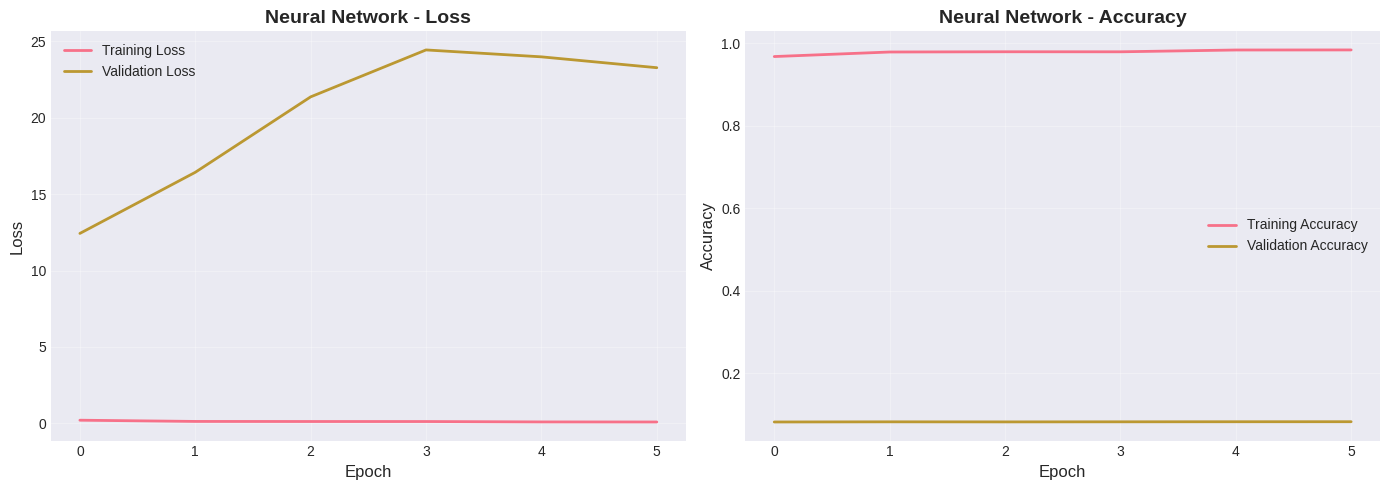

In [17]:
# -------------------------------
# Model 5: Neural Network (GPU-Accelerated)
# -------------------------------
print("\n[5/5] Training Neural Network (GPU-Accelerated)...")
start_time = time.time()

# Convert labels to categorical (one-hot encoding) for neural network
print("  Converting labels to one-hot encoding...")
from tensorflow.keras.utils import to_categorical

# Get number of classes from the LabelEncoder (already fitted earlier)
n_classes = len(le.classes_)  # Use the LabelEncoder's classes count

# Convert training labels to one-hot encoding
y_train_categorical = to_categorical(y_train_balanced, num_classes=n_classes)

print(f"  ✓ Converted labels to one-hot encoding ({n_classes} classes)")

# Build Neural Network
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    nn_model = models.Sequential([
        layers.Input(shape=(len(feature_names),)),

        # First hidden layer
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Second hidden layer
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Third hidden layer
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Output layer
        layers.Dense(n_classes, activation='softmax')
    ])

    # Compile model
    nn_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print("\nNeural Network Architecture:")
nn_model.summary()

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# Train
print("\nTraining Neural Network...")
history = nn_model.fit(
    X_train_balanced.values,
    y_train_categorical,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Predictions
y_pred_proba_nn = nn_model.predict(X_test_scaled.values, verbose=0)
y_pred_nn = np.argmax(y_pred_proba_nn, axis=1)

# Metrics
nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn, average='weighted', zero_division=0)
nn_recall = recall_score(y_test, y_pred_nn, average='weighted', zero_division=0)
nn_f1 = f1_score(y_test, y_pred_nn, average='weighted', zero_division=0)

train_time_nn = time.time() - start_time

all_models_results.append({
    'Model': 'Neural Network',
    'Accuracy': nn_accuracy,
    'Precision': nn_precision,
    'Recall': nn_recall,
    'F1-Score': nn_f1,
    'Training Time': train_time_nn
})

print(f"\n  ✓ Completed in {train_time_nn:.2f}s")
print(f"    Accuracy: {nn_accuracy:.4f} | F1-Score: {nn_f1:.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1 = axes[0]
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Neural Network - Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy
ax2 = axes[1]
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Neural Network - Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

# SECTION 7: MODEL COMPARISON


MODEL COMPARISON

Performance Summary:
              Model  Accuracy  Precision   Recall  F1-Score  Training Time
            XGBoost  0.998354   0.998739 0.998354  0.998485      76.206379
      Random Forest  0.994812   0.997945 0.994812  0.996140     676.946502
     Neural Network  0.949353   0.967798 0.949353  0.955978     207.530984
Logistic Regression  0.837166   0.956690 0.837166  0.883878     207.463611
           LightGBM  0.557952   0.830099 0.557952  0.647190     786.658183


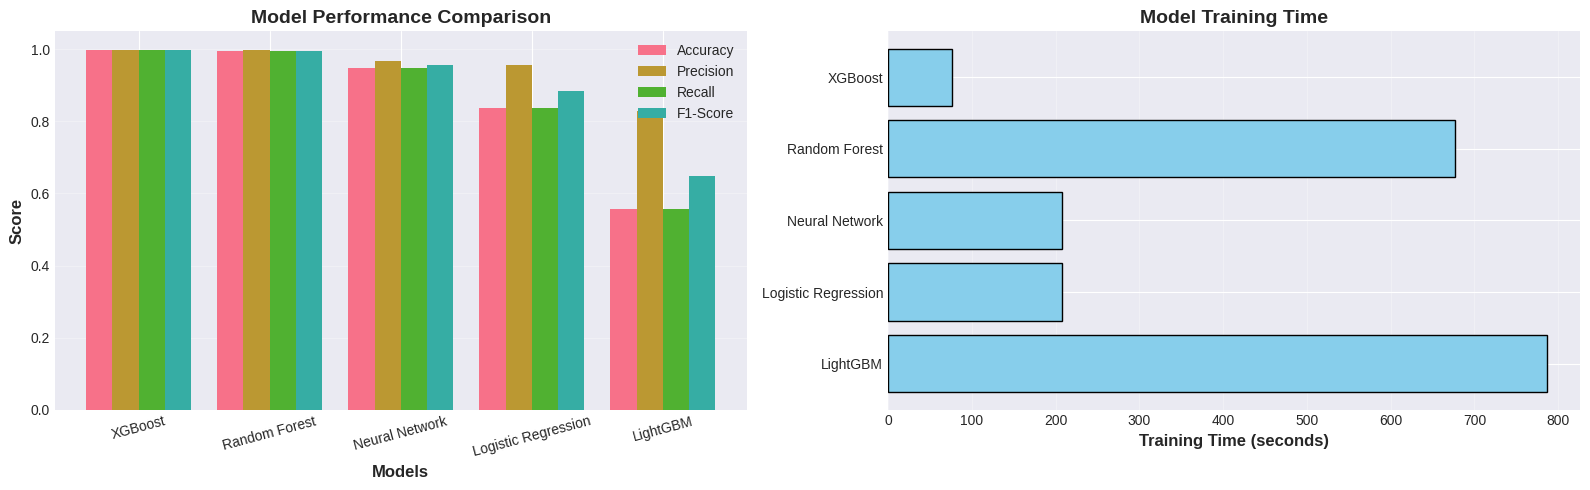


🏆 Best Model: XGBoost (F1-Score: 0.9985)


In [18]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Create results dataframe
results_df = pd.DataFrame(all_models_results)
results_df = results_df.sort_values('F1-Score', ascending=False)

print("\nPerformance Summary:")
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Metrics Comparison
ax1 = axes[0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax1.bar(x + i * width, results_df[metric], width, label=metric)

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(results_df['Model'], rotation=15)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Training Time
ax2 = axes[1]
ax2.barh(results_df['Model'], results_df['Training Time'], color='skyblue', edgecolor='black')
ax2.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Model Training Time', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_gpu.png', dpi=100, bbox_inches='tight')
plt.show()

# Best model
best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
print(f"\n🏆 Best Model: {best_model_name} (F1-Score: {best_f1:.4f})")



# SECTION 8: CONFUSION MATRICES


CONFUSION MATRICES


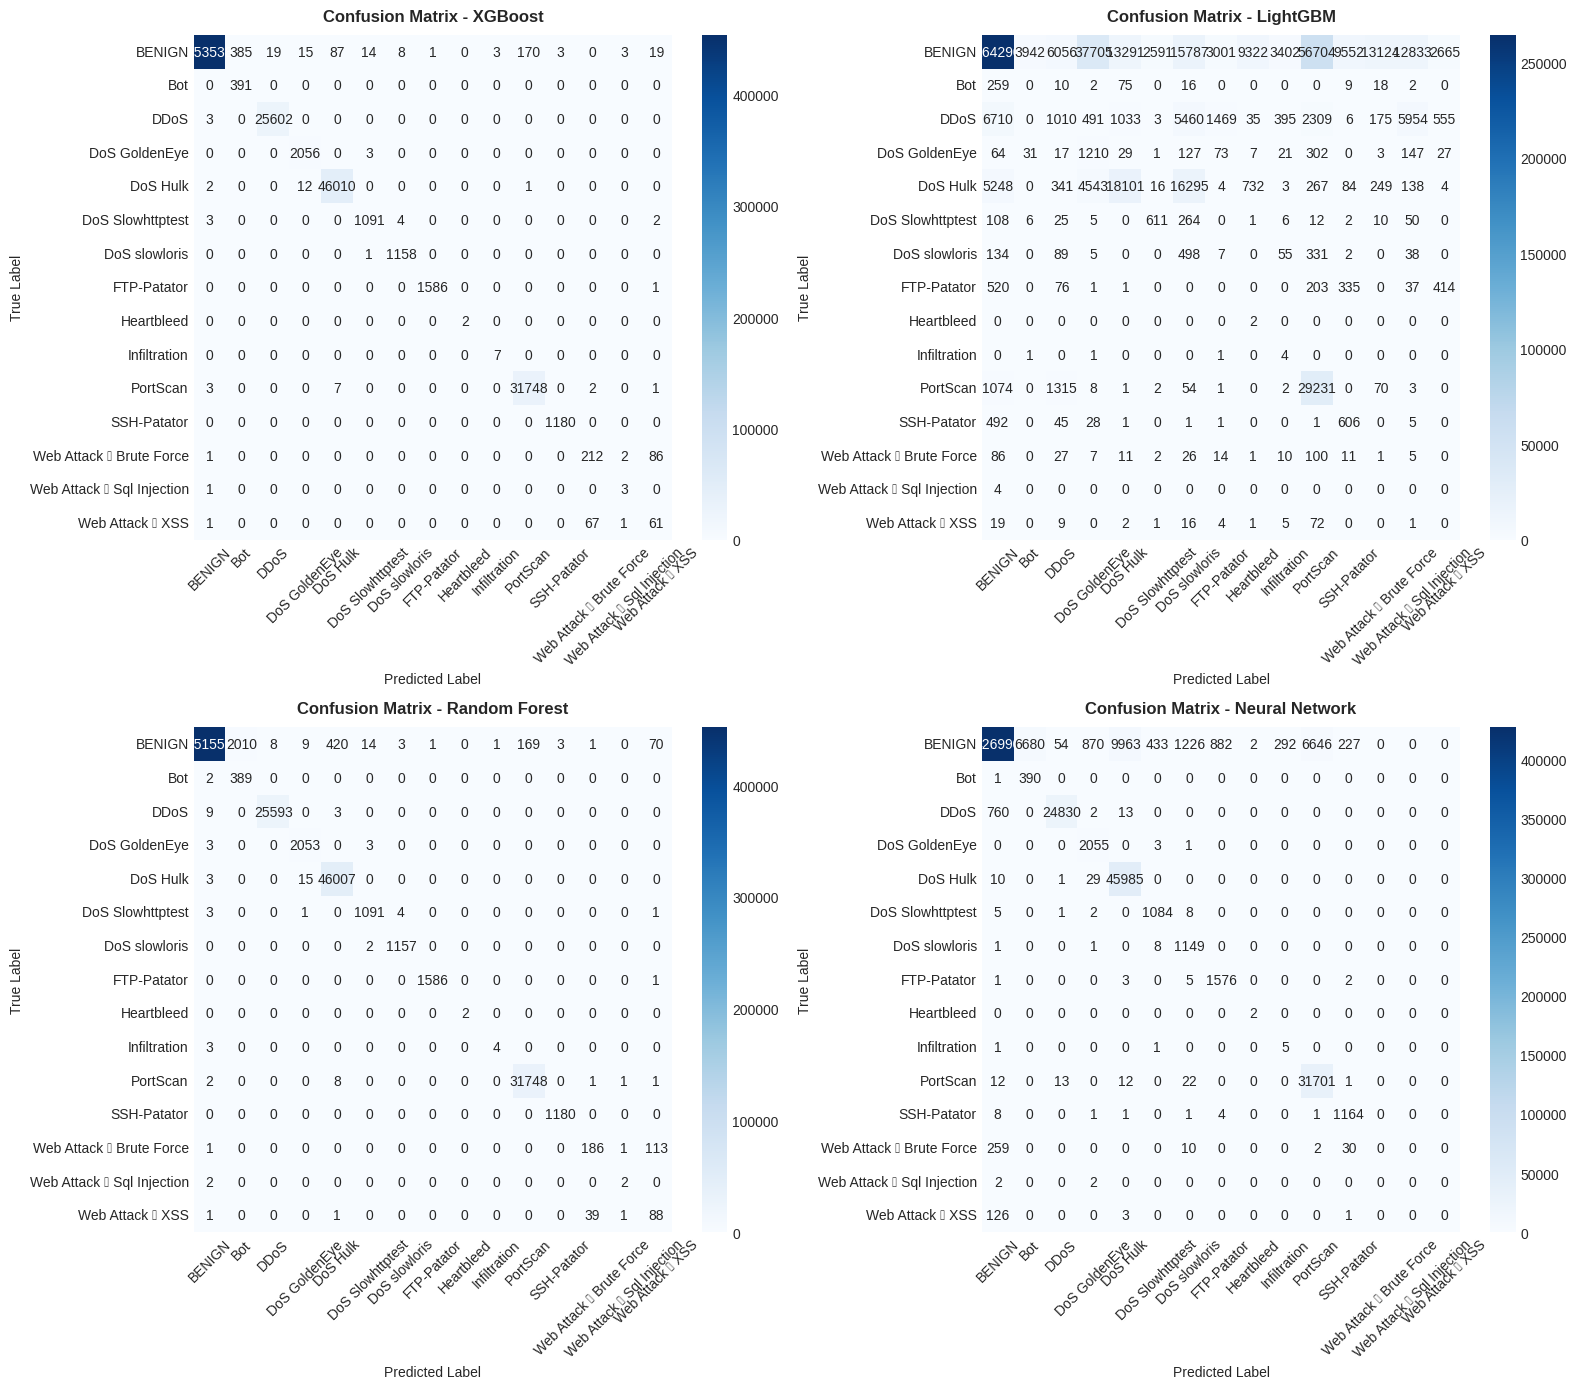


Detailed Classification Reports:

XGBoost
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    454265
                       Bot       0.50      1.00      0.67       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       0.99      1.00      0.99      2059
                  DoS Hulk       1.00      1.00      1.00     46025
          DoS Slowhttptest       0.98      0.99      0.99      1100
             DoS slowloris       0.99      1.00      0.99      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       0.70      1.00      0.82         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack � Brute Force       0.75      0.70      0.73       301
Web 

In [19]:
print("\n" + "=" * 60)
print("CONFUSION MATRICES")
print("=" * 60)

# Create confusion matrices for all models
predictions = {
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb,
    'Random Forest': y_pred_rf,
    'Neural Network': y_pred_nn
}

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=True)
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices_gpu.png', dpi=100, bbox_inches='tight')
plt.show()

# Classification reports
print("\nDetailed Classification Reports:")
for model_name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f"{model_name}")
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))



# SECTION 9: FEATURE IMPORTANCE


FEATURE IMPORTANCE ANALYSIS


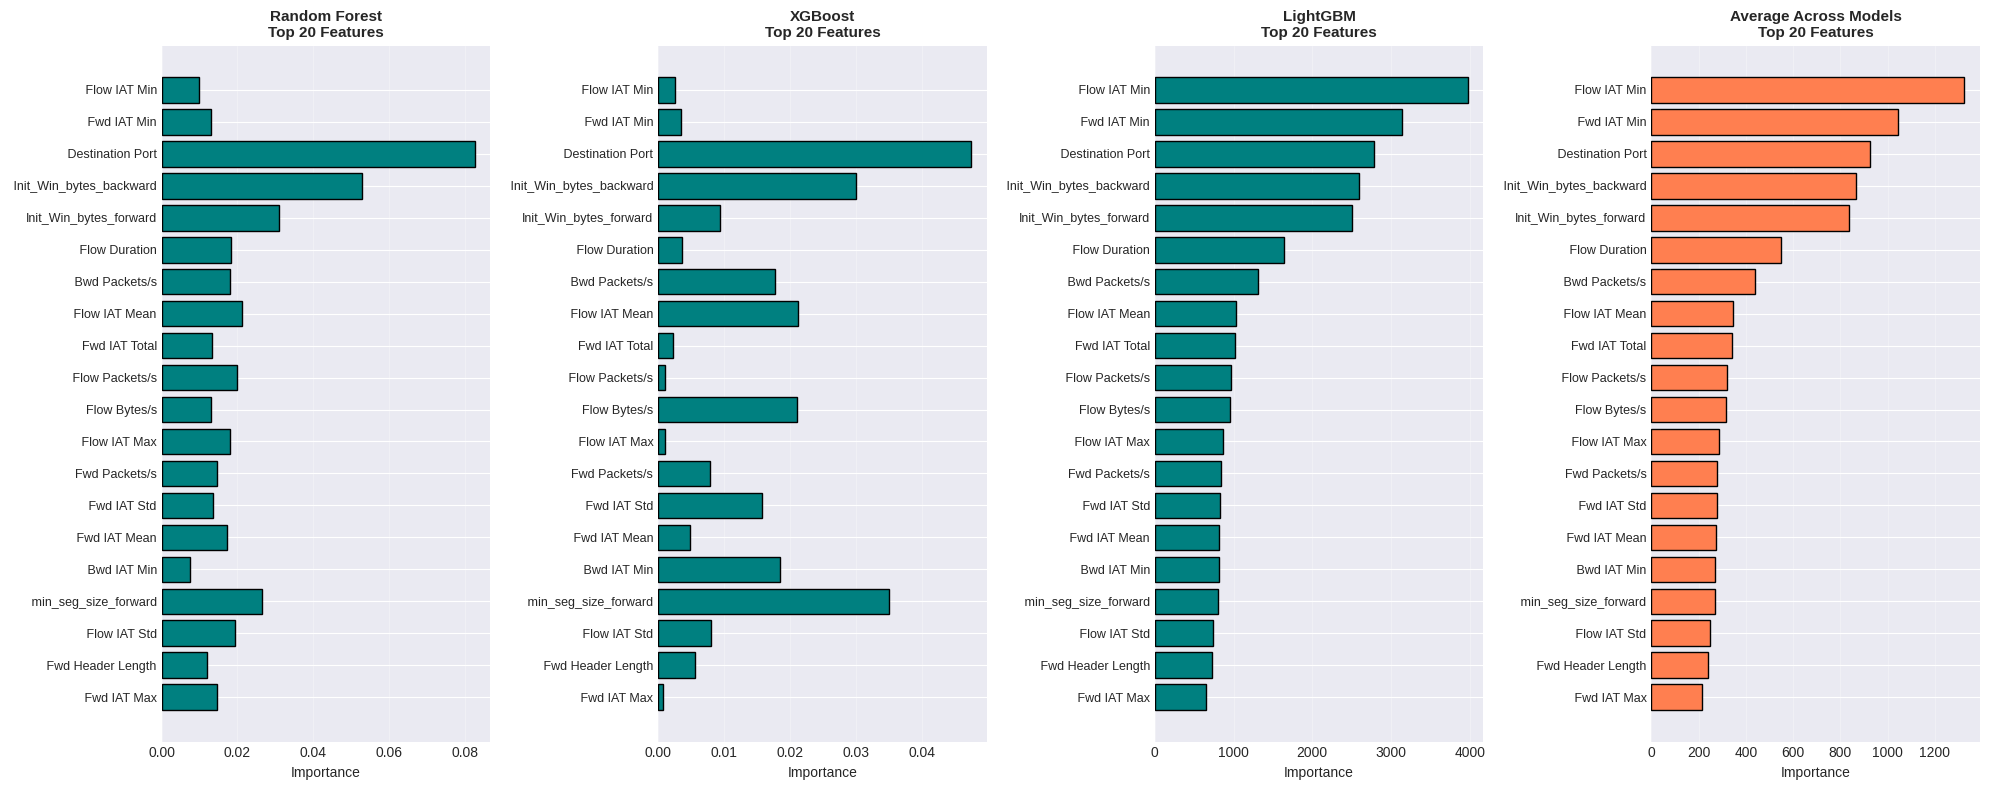


Top 10 Most Important Features (Average):
   1.  Flow IAT Min                           : 1325.004120
   2.  Fwd IAT Min                            : 1045.672132
   3.  Destination Port                       : 927.376696
   4.  Init_Win_bytes_backward                : 864.694302
   5. Init_Win_bytes_forward                  : 835.680177
   6.  Flow Duration                          : 547.340620
   7.  Bwd Packets/s                          : 437.345263
   8.  Flow IAT Mean                          : 344.680775
   9. Fwd IAT Total                           : 340.338490
  10.  Flow Packets/s                         : 321.006992


In [20]:
print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Collect feature importances from tree-based models
importance_dict = {}

if rf_model:
    importance_dict['Random Forest'] = rf_model.feature_importances_

if xgb_model:
    importance_dict['XGBoost'] = xgb_model.feature_importances_

if lgb_model:
    importance_dict['LightGBM'] = lgb_model.feature_importances_

if importance_dict:
    # Create dataframe
    importance_df = pd.DataFrame(importance_dict, index=feature_names)
    importance_df['Average'] = importance_df.mean(axis=1)
    importance_df_sorted = importance_df.sort_values('Average', ascending=False)

    # Plot top 20 features
    fig, axes = plt.subplots(1, len(importance_dict) + 1, figsize=(20, 8))

    for idx, (model_name, ax) in enumerate(zip(importance_dict.keys(), axes[:-1])):
        top_features = importance_df_sorted[model_name].head(20)
        ax.barh(range(len(top_features)), top_features.values, color='teal', edgecolor='black')
        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features.index, fontsize=9)
        ax.set_xlabel('Importance', fontsize=10)
        ax.set_title(f'{model_name}\nTop 20 Features', fontsize=11, fontweight='bold')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

    # Average importance
    ax_avg = axes[-1]
    top_avg = importance_df_sorted['Average'].head(20)
    ax_avg.barh(range(len(top_avg)), top_avg.values, color='coral', edgecolor='black')
    ax_avg.set_yticks(range(len(top_avg)))
    ax_avg.set_yticklabels(top_avg.index, fontsize=9)
    ax_avg.set_xlabel('Importance', fontsize=10)
    ax_avg.set_title('Average Across Models\nTop 20 Features', fontsize=11, fontweight='bold')
    ax_avg.invert_yaxis()
    ax_avg.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('feature_importance_gpu.png', dpi=100, bbox_inches='tight')
    plt.show()

    print("\nTop 10 Most Important Features (Average):")
    for idx, (feature, importance) in enumerate(importance_df_sorted['Average'].head(10).items(), 1):
        print(f"  {idx:2d}. {feature:40s}: {importance:.6f}")



# SECTION 10: ROC CURVES


ROC CURVES (Binary: Benign vs Attack)


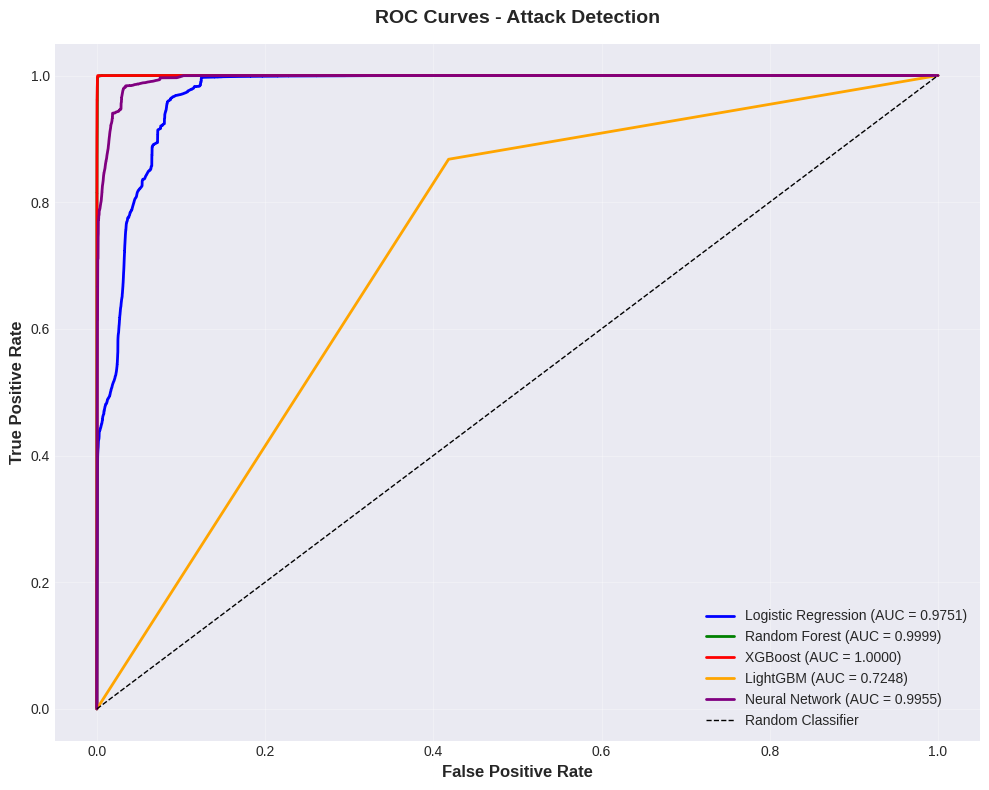

In [21]:
print("\n" + "=" * 60)
print("ROC CURVES (Binary: Benign vs Attack)")
print("=" * 60)

# Convert to binary classification for ROC
y_test_binary = (y_test != 0).astype(int)

# Get probabilities for attack class (any non-benign)
def get_attack_proba(y_proba):
    # Sum probabilities of all attack classes (exclude benign which is class 0)
    if len(y_proba.shape) > 1:
        return 1 - y_proba[:, 0]  # 1 - P(benign)
    return y_proba

fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC for each model
models_roc = {
    'Logistic Regression': get_attack_proba(y_pred_proba_lr),
    'Random Forest': get_attack_proba(y_pred_proba_rf),
    'XGBoost': get_attack_proba(y_pred_proba_xgb),
    'LightGBM': get_attack_proba(y_pred_proba_lgb),
    'Neural Network': get_attack_proba(y_pred_proba_nn)
}

colors = ['blue', 'green', 'red', 'orange', 'purple']

for (model_name, y_proba), color in zip(models_roc.items(), colors):
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    auc_score = roc_auc_score(y_test_binary, y_proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})',
            linewidth=2, color=color)

# Plot diagonal
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Attack Detection', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_gpu.png', dpi=100, bbox_inches='tight')
plt.show()



# SECTION 11: SAVE MODELS

In [22]:
print("\n" + "=" * 60)
print("SAVING MODELS")
print("=" * 60)

import joblib

# Create directory
os.makedirs('models', exist_ok=True)

print("\nSaving models to ./models/ directory...")

saved_models = []

# Save Random Forest
if rf_model:
    joblib.dump(rf_model, 'models/random_forest_gpu.pkl')
    saved_models.append('Random Forest')
    print("  ✓ Saved: random_forest_gpu.pkl")

# Save XGBoost
if xgb_model:
    joblib.dump(xgb_model, 'models/xgboost_ids_gpu.pkl')
    saved_models.append('XGBoost')
    print("  ✓ Saved: xgboost_ids_gpu.pkl")

# Save LightGBM
if lgb_model:
    joblib.dump(lgb_model, 'models/lightgbm_ids_gpu.pkl')
    saved_models.append('LightGBM')
    print("  ✓ Saved: lightgbm_ids_gpu.pkl")

# Save Logistic Regression
if lr_model:
    joblib.dump(lr_model, 'models/logistic_regression_gpu.pkl')
    saved_models.append('Logistic Regression')
    print("  ✓ Saved: logistic_regression_gpu.pkl")

# Save Neural Network
if nn_model:
    nn_model.save('models/neural_network_ids_gpu.h5')
    saved_models.append('Neural Network')
    print("  ✓ Saved: neural_network_ids_gpu.h5")

# Save preprocessing objects
joblib.dump(scaler, 'models/scaler_gpu.pkl')
joblib.dump(le, 'models/label_encoder_gpu.pkl')
print("  ✓ Saved: scaler_gpu.pkl")
print("  ✓ Saved: label_encoder_gpu.pkl")

print(f"\n✓ Successfully saved {len(saved_models)} models!")
print(f"  Saved Models: {', '.join(saved_models)}")




SAVING MODELS

Saving models to ./models/ directory...
  ✓ Saved: random_forest_gpu.pkl
  ✓ Saved: xgboost_ids_gpu.pkl


  ✓ Saved: lightgbm_ids_gpu.pkl
  ✓ Saved: logistic_regression_gpu.pkl
  ✓ Saved: neural_network_ids_gpu.h5
  ✓ Saved: scaler_gpu.pkl
  ✓ Saved: label_encoder_gpu.pkl

✓ Successfully saved 5 models!
  Saved Models: Random Forest, XGBoost, LightGBM, Logistic Regression, Neural Network


# SECTION 12: FINAL SUMMARY

In [23]:
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"\nDataset Summary:")
print(f"  Total Samples: {len(y_train_balanced) + len(y_test):,}")
print(f"  Features: {len(feature_names)}")
print(f"  Attack Types: {len(le.classes_)}")
print(f"  Training Samples (after SMOTE): {len(y_train_balanced):,}")
print(f"  Test Samples: {len(y_test):,}")

print("\nModels Trained:")
for i, model in enumerate(saved_models, 1):
    print(f"  {i}. {model}")

print(f"\nBest Performing Model:")
print(f"  Model: {best_model_name}")
print(f"  Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"  Precision: {results_df.iloc[0]['Precision']:.4f}")
print(f"  Recall: {results_df.iloc[0]['Recall']:.4f}")
print(f"  F1-Score: {best_f1:.4f}")

if gpus:
    print(f"\n✓ GPU Acceleration: Enabled ({len(gpus)} GPU(s))")
else:
    print(f"\n⚠ GPU Acceleration: Not Available (CPU used)")

print("\n" + "=" * 60)
print("✓ TRAINING COMPLETE!")
print("=" * 60)

# Final memory cleanup
print("\nPerforming final memory cleanup...")
gc.collect()
if gpus:
    tf.keras.backend.clear_session()
print("✓ Memory cleanup complete")


FINAL SUMMARY

Dataset Summary:
  Total Samples: 2,793,860
  Features: 78
  Attack Types: 15
  Training Samples (after SMOTE): 2,228,284
  Test Samples: 565,576

Models Trained:
  1. Random Forest
  2. XGBoost
  3. LightGBM
  4. Logistic Regression
  5. Neural Network

Best Performing Model:
  Model: XGBoost
  Accuracy: 0.9984
  Precision: 0.9987
  Recall: 0.9984
  F1-Score: 0.9985

✓ GPU Acceleration: Enabled (1 GPU(s))

✓ TRAINING COMPLETE!

Performing final memory cleanup...
✓ Memory cleanup complete
